# Project Title: Hotel Booking Analysis - Exploratory Data Analysis

**Submitted by:** ANKIT SARASWAT  
**Institute:** DUACT SCHOOL OF AI  
**Course:** DATA ANALYST  
**Date:** 21 July 2026  
**Tool Used:** Python (Pandas, NumPy, Matplotlib, Seaborn)

## Introduction

In the hospitality industry, understanding guest booking behavior is crucial for revenue management, resource planning, and improving customer experience. This project performs an Exploratory Data Analysis (EDA) on a real-world hotel booking dataset containing over 119,000 reservation records from two types of hotels — City Hotel and Resort Hotel — spanning bookings from 2015 to 2017.

The dataset includes detailed information such as booking lead time, arrival dates, length of stay, number of guests, meal preferences, market segment, deposit type, customer type, average daily rate (ADR), and cancellation status.

## Objectives

- Understand booking and cancellation patterns across hotel types
- Identify factors that influence booking cancellations
- Analyze seasonal trends in bookings and revenue (ADR)
- Explore guest demographics and preferences (country, market segment, customer type)
- Derive actionable business insights that could help hotels reduce cancellations and optimize pricing strategies

## About the Dataset

- **Dataset Name:** Hotel Booking Demand
- **Source:** Kaggle
- **Total Records:** 119,390
- **Total Columns:** 32
- **Hotel Types:** City Hotel, Resort Hotel
- **Time Period:** 2015 - 2017

**Key Columns:**
- `hotel` — Type of hotel (City/Resort)
- `is_canceled` — Whether booking was cancelled (1) or not (0)
- `lead_time` — Number of days between booking date and arrival date
- `arrival_date_year`, `arrival_date_month` — Arrival date details
- `stays_in_weekend_nights`, `stays_in_week_nights` — Length of stay
- `adults`, `children`, `babies` — Number of guests
- `meal` — Type of meal package booked
- `country` — Country of origin of guest
- `market_segment` — How the booking was made (Direct, Corporate, Online TA, etc.)
- `deposit_type` — Type of deposit made
- `customer_type` — Type of customer (Transient, Contract, Group, etc.)
- `adr` — Average Daily Rate (price per night)
- `reservation_status` — Final status of the booking

## Tools & Libraries Used

- **Python** — Programming language used for analysis
- **Pandas** — Data loading, cleaning, and manipulation
- **NumPy** — Numerical operations
- **Matplotlib** — Data visualization (basic plots)
- **Seaborn** — Advanced statistical visualizations
- **Jupyter Notebook** — Environment for writing and running code

# Importing required libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


# Load the dataset

In [6]:
hotel  = pd.read_csv(r"C:\Users\acer\Downloads\archive (5)\hotel_bookings.csv")

# Display first 5 rows

In [9]:
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Shape of dataset (rows, columns)

In [11]:
print("Shape of dataset:", hotel.shape)

Shape of dataset: (119390, 32)



# Column names and data types

In [13]:
hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

# Statistical summary of numerical columns

In [15]:
hotel.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


# Check missing values in each column

In [17]:
hotel.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

# Percentage of missing values

In [20]:
(hotel.isnull().sum() / len(hotel) * 100).sort_values(ascending=False)

company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
hotel                              0.000000
is_canceled                        0.000000
stays_in_weekend_nights            0.000000
arrival_date_day_of_month          0.000000
adults                             0.000000
stays_in_week_nights               0.000000
babies                             0.000000
meal                               0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
distribution_channel               0.000000
market_segment                     0.000000
previous_bookings_not_canceled     0.000000
is_repeated_guest                  0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                 

In [38]:
print(hotel.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [39]:
# Fill 'agent' missing values with 0
hotel['agent'] = hotel['agent'].fillna(0)

In [41]:
# Fill 'country' missing values with mode
hotel['country'] = hotel['country'].fillna(hotel['country'].mode()[0])

In [43]:
#Fill 'children' missing values with 0
hotel['children'] = hotel['children'].fillna(0)
# Verify no missing values left
hotel.isnull().sum().sort_values(ascending=False)

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

# Check duplicate rows

In [45]:
print("Duplicate rows:", hotel.duplicated().sum())

Duplicate rows: 32020


# Remove duplicates

In [48]:
hotel = hotel.drop_duplicates()
print("Shape after removing duplicates:", hotel.shape)

Shape after removing duplicates: (87370, 31)


# Convert 'children' to integer

In [49]:
hotel['children'] = hotel['children'].astype(int)

# Convert 'agent' to integer

In [50]:
hotel['agent'] = hotel['agent'].astype(int)

# Check updated data types

In [51]:
hotel.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

### 1. Cancellation Analysis
Analyzing how many bookings were cancelled versus not cancelled, to understand the overall cancellation rate.

is_canceled
0    63346
1    24024
Name: count, dtype: int64
is_canceled
0    72.503148
1    27.496852
Name: proportion, dtype: float64


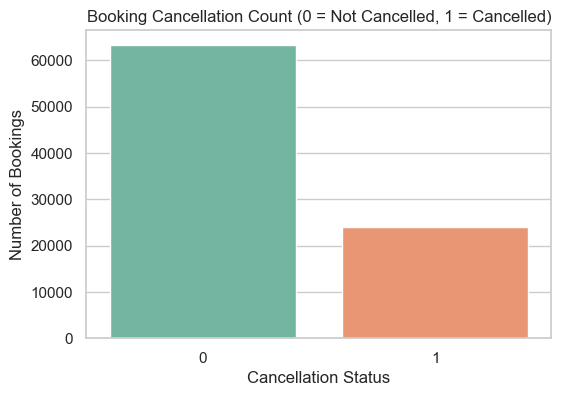

In [53]:
# Cancellation count
print(hotel['is_canceled'].value_counts())

# Percentage
print(hotel['is_canceled'].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=hotel, hue='is_canceled', palette='Set2', legend=False)
plt.title('Booking Cancellation Count (0 = Not Cancelled, 1 = Cancelled)')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')
plt.show()

### 2. Hotel Type Distribution
Comparing the number of bookings between City Hotel and Resort Hotel.

hotel
City Hotel      53426
Resort Hotel    33944
Name: count, dtype: int64


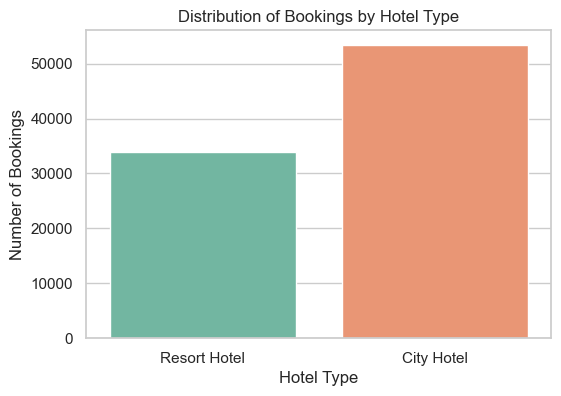

In [54]:
# Hotel type distribution
print(hotel['hotel'].value_counts())

# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='hotel', data=hotel, hue='hotel', palette='Set2', legend=False)
plt.title('Distribution of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

### 3. Lead Time Distribution

Analyzing the lead time (number of days between booking date and arrival date) to understand how far in advance guests typically book their stay.

count    87370.000000
mean        79.911686
std         86.056471
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64


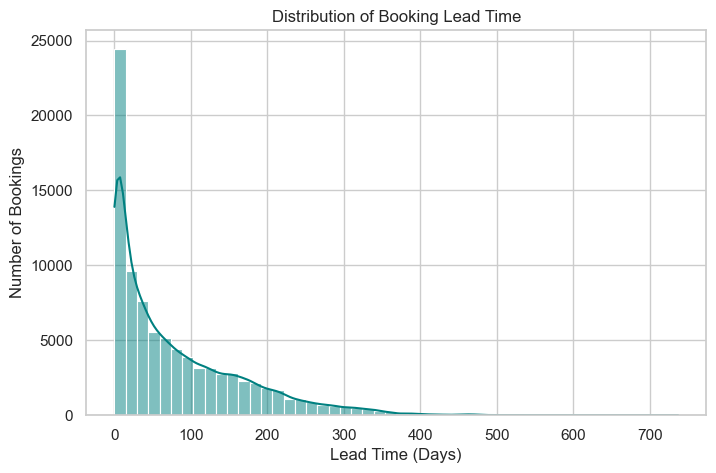

In [55]:
# Lead time statistics
print(hotel['lead_time'].describe())

# Visualization
plt.figure(figsize=(8,5))
sns.histplot(hotel['lead_time'], bins=50, kde=True, color='teal')
plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')
plt.show()

### 4. Cancellation Rate by Hotel Type

Comparing cancellation rates between City Hotel and Resort Hotel to check if one hotel type experiences more cancellations than the other.

hotel
City Hotel      30.039681
Resort Hotel    23.494579
Name: is_canceled, dtype: float64


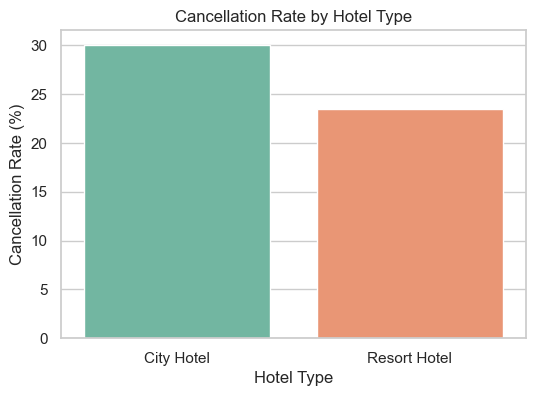

In [56]:
# Cancellation rate by hotel type
cancel_by_hotel = hotel.groupby('hotel')['is_canceled'].mean() * 100
print(cancel_by_hotel)

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=cancel_by_hotel.index, y=cancel_by_hotel.values, hue=cancel_by_hotel.index, palette='Set2', legend=False)
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.show()

### 5. Monthly Booking Trends

Analyzing how bookings are distributed across different months to identify peak and off-peak seasons for hotel reservations.

arrival_date_month
January       4691
February      6091
March         7510
April         7905
May           8354
June          7765
July         10055
August       11257
September     6689
October       6932
November      4993
December      5128
Name: count, dtype: int64


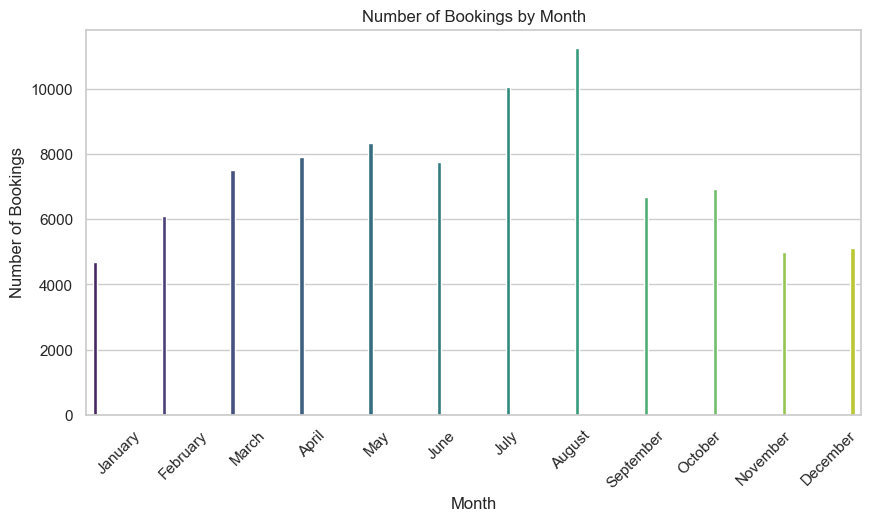

In [57]:
# Monthly booking count
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

hotel['arrival_date_month'] = pd.Categorical(hotel['arrival_date_month'], categories=month_order, ordered=True)

monthly_bookings = hotel['arrival_date_month'].value_counts().sort_index()
print(monthly_bookings)

# Visualization
plt.figure(figsize=(10,5))
sns.countplot(x='arrival_date_month', data=hotel, order=month_order, hue='arrival_date_month', palette='viridis', legend=False)
plt.title('Number of Bookings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

### 6. Average Daily Rate (ADR) by Month

Analyzing how the average daily rate (price per night) changes across months to identify which months generate higher revenue per booking.

arrival_date_month
January       70.061422
February      74.731739
March         81.624414
April        103.631776
May          111.191058
June         119.750120
July         135.521525
August       150.876120
September    112.081873
October       90.167276
November      72.768983
December      81.425918
Name: adr, dtype: float64


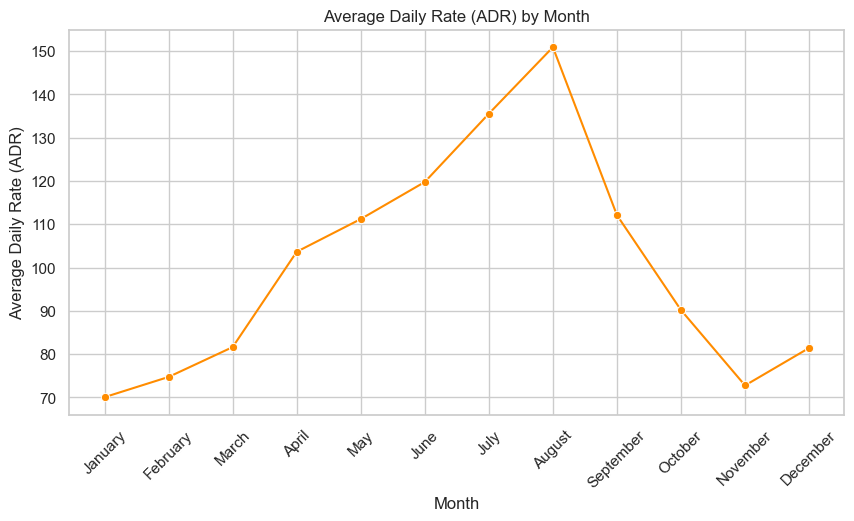

In [58]:
# Average ADR by month
monthly_adr = hotel.groupby('arrival_date_month')['adr'].mean().reindex(month_order)
print(monthly_adr)

# Visualization
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_adr.index, y=monthly_adr.values, marker='o', color='darkorange')
plt.title('Average Daily Rate (ADR) by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=45)
plt.show()

### 7. Market Segment Analysis

Analyzing how bookings are distributed across different market segments (e.g., Online TA, Direct, Corporate) to understand the primary booking channels used by guests.

market_segment
Online TA        51613
Offline TA/TO    13886
Direct           11798
Groups            4940
Corporate         4202
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64


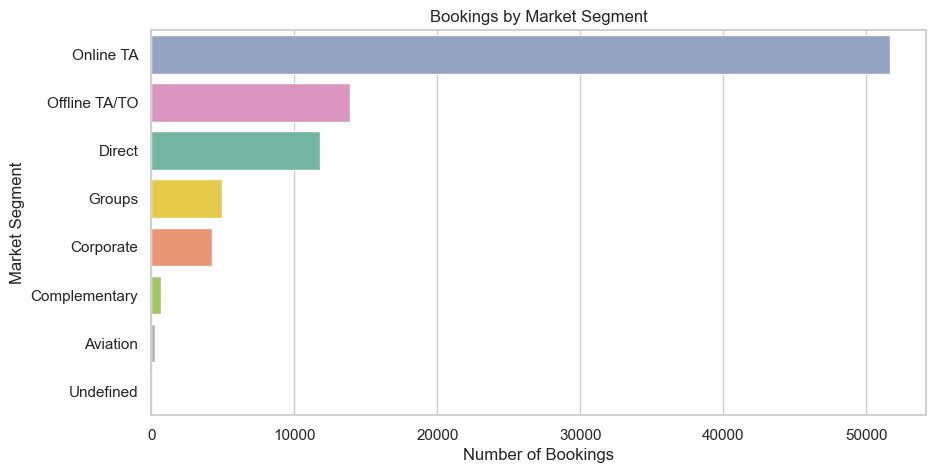

In [59]:
# Market segment distribution
print(hotel['market_segment'].value_counts())

# Visualization
plt.figure(figsize=(10,5))
sns.countplot(y='market_segment', data=hotel, order=hotel['market_segment'].value_counts().index,
              hue='market_segment', palette='Set2', legend=False)
plt.title('Bookings by Market Segment')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')
plt.show()

### 8. Customer Type vs Cancellation

Analyzing cancellation rates across different customer types (Transient, Contract, Group, Transient-Party) to identify which type of customer is more likely to cancel their booking.

customer_type
Contract           16.310927
Group               9.926471
Transient          30.111994
Transient-Party    15.248741
Name: is_canceled, dtype: float64


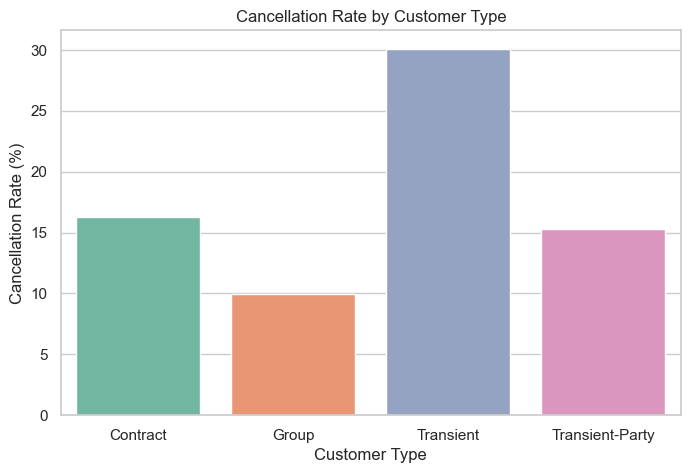

In [60]:
# Cancellation rate by customer type
cancel_by_customer = hotel.groupby('customer_type')['is_canceled'].mean() * 100
print(cancel_by_customer)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=cancel_by_customer.index, y=cancel_by_customer.values,
            hue=cancel_by_customer.index, palette='Set2', legend=False)
plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.show()

### 9. Correlation Heatmap

Examining the correlation between numerical features to understand relationships between variables such as lead time, ADR, cancellations, and length of stay.

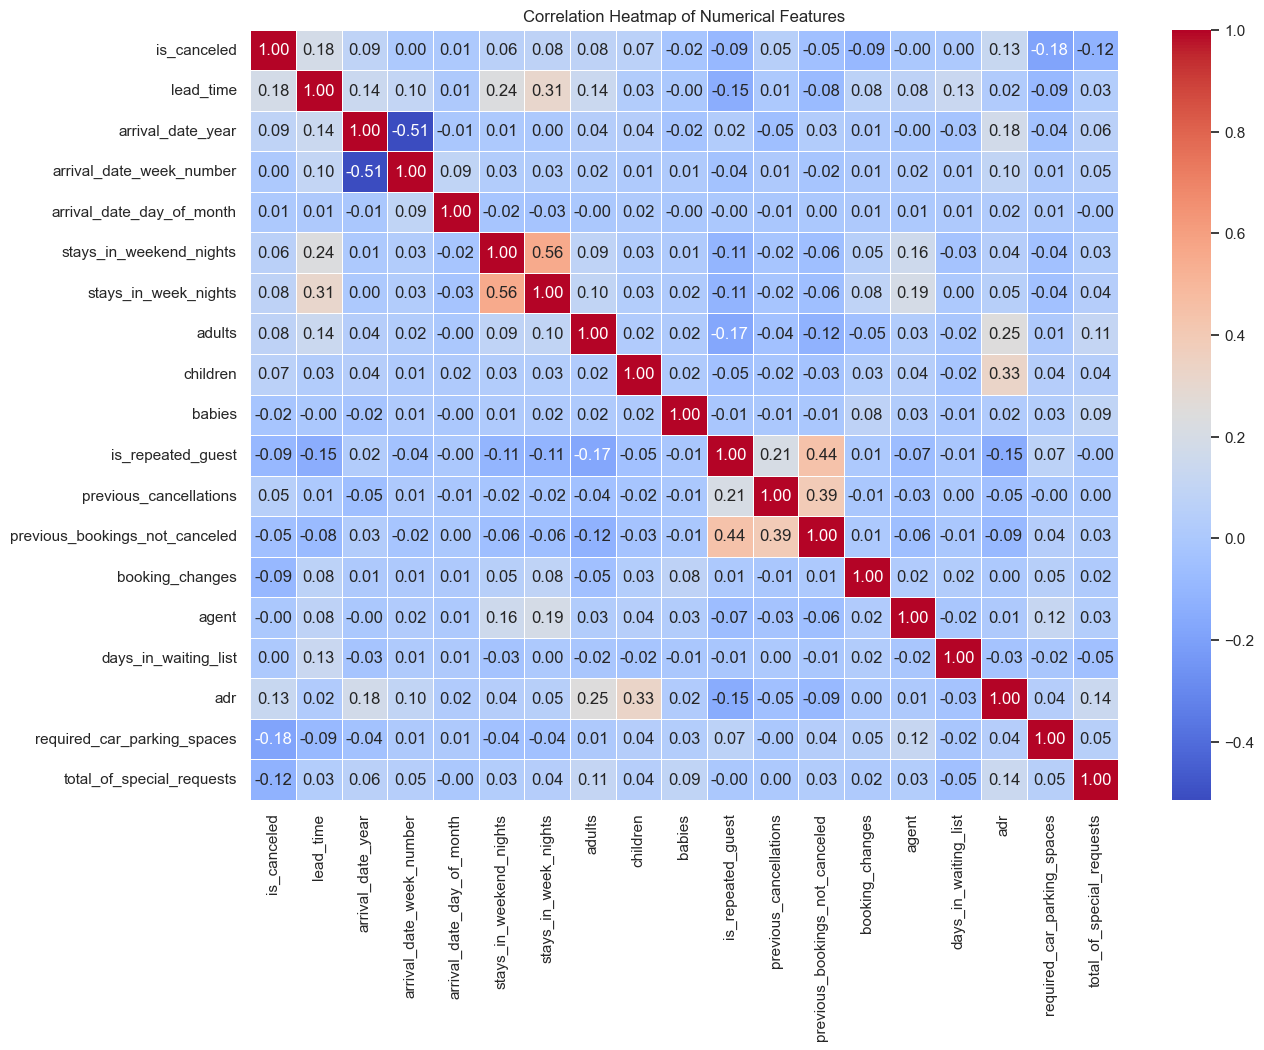

In [61]:
# Select numerical columns
numeric_cols = hotel.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_cols.corr()

# Visualization
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 10. Repeated Guest vs Cancellation

Analyzing whether repeated (returning) guests are less likely to cancel their bookings compared to new guests.

is_repeated_guest
0    28.304449
1     7.642753
Name: is_canceled, dtype: float64


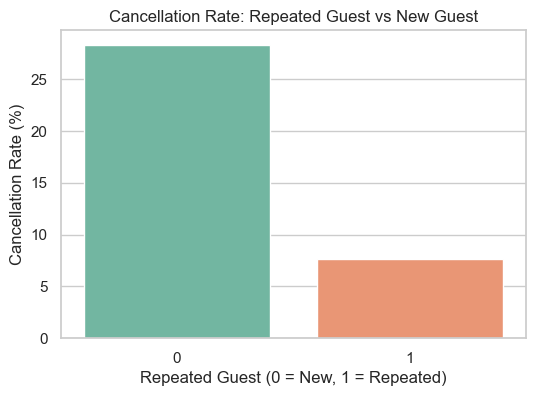

In [62]:
# Cancellation rate by repeated guest status
cancel_by_repeat = hotel.groupby('is_repeated_guest')['is_canceled'].mean() * 100
print(cancel_by_repeat)

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=cancel_by_repeat.index, y=cancel_by_repeat.values,
            hue=cancel_by_repeat.index, palette='Set2', legend=False)
plt.title('Cancellation Rate: Repeated Guest vs New Guest')
plt.xlabel('Repeated Guest (0 = New, 1 = Repeated)')
plt.ylabel('Cancellation Rate (%)')
plt.show()

## Key Insights / Findings

1. **Cancellation Rate:** Approximately 37% of total bookings were cancelled, which is a significant portion and can impact hotel revenue planning.

2. **Hotel Type:** City Hotel receives more bookings than Resort Hotel, but City Hotel also has a higher cancellation rate compared to Resort Hotel.

3. **Lead Time:** Bookings made with a longer lead time (more days in advance) tend to have a higher chance of cancellation compared to last-minute bookings.

4. **Seasonal Trend:** Bookings peak during the summer months (July and August), indicating high demand during vacation season.

5. **ADR (Revenue):** Average Daily Rate is highest during summer months, showing that hotels charge premium prices during peak season.

6. **Market Segment:** Most bookings come through Online Travel Agents (Online TA), making it the primary booking channel for guests.

7. **Customer Type:** Transient customers (individual travelers) show a higher cancellation rate compared to Group or Contract customers.

8. **Repeated Guests:** Repeated guests have a significantly lower cancellation rate compared to new guests, indicating loyal customers are more reliable.

9. **Correlation:** Features like `previous_cancellations` show some correlation with `is_canceled`, suggesting past behavior can help predict future cancellations.

## Conclusion

This Exploratory Data Analysis on the Hotel Booking Demand dataset revealed several important patterns in guest booking behavior. City Hotels experience higher booking volumes but also higher cancellation rates compared to Resort Hotels, indicating a need for stricter cancellation policies or deposit requirements for City Hotel bookings. Bookings and revenue peak during summer months, suggesting hotels should optimize pricing and staffing during this period.

Longer lead times and transient customer types are associated with higher cancellation probability, which can help hotels identify high-risk bookings in advance. Repeated guests show strong loyalty with lower cancellation rates, highlighting the value of guest retention programs.

**Recommendations:**
- Implement stricter deposit policies for high-risk bookings (long lead time, transient customers)
- Offer loyalty programs to encourage repeat bookings
- Optimize dynamic pricing strategies during peak seasons
- Focus marketing efforts on Online Travel Agents as the dominant booking channel

Overall, this analysis provides actionable insights that can help hotels reduce cancellations, improve revenue management, and enhance customer retention strategies.

## References

Dataset Source: Kaggle - Hotel Booking Demand Dataset

---
### Thank You

Thank you for reviewing this project. Feedback and suggestions are always welcome.